In [10]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
%matplotlib inline
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [3]:
data = pd.read_csv(r"Dataset\csv\loan_approval_dataset.csv")
data.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [4]:
#NOW WE WILL PERFORM EDA

In [5]:
#UNIVARIATE ANANYLIS(SINGLE VARIABLE)
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   loan_id                    4269 non-null   int64
 1    no_of_dependents          4269 non-null   int64
 2    education                 4269 non-null   str  
 3    self_employed             4269 non-null   str  
 4    income_annum              4269 non-null   int64
 5    loan_amount               4269 non-null   int64
 6    loan_term                 4269 non-null   int64
 7    cibil_score               4269 non-null   int64
 8    residential_assets_value  4269 non-null   int64
 9    commercial_assets_value   4269 non-null   int64
 10   luxury_assets_value       4269 non-null   int64
 11   bank_asset_value          4269 non-null   int64
 12   loan_status               4269 non-null   str  
dtypes: int64(10), str(3)
memory usage: 531.6 KB


In [7]:
#ALWAYS MAKE A BACKUP COPY OF THE DATA
data_original = data.copy()

In [16]:
data.columns = data.columns.str.strip()

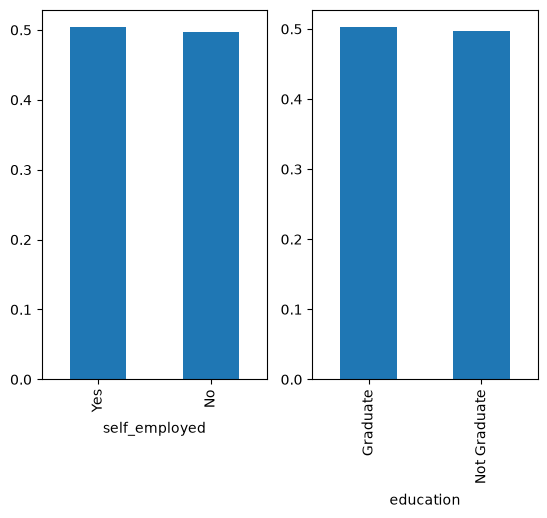

In [17]:
#CATEGORICAL VARIABLES - [SELF EMPLOYED,GRADUATE]
#ORDINAL VARIABLE - NONE
#NUMERICAL - [ALL OTHER]
#NOW PERFORMING UnvAnalysis
plt.figure(1)
plt.subplot(121)
data['self_employed'].value_counts(normalize =True).plot(kind = 'bar')

plt.subplot(122)
data['education'].value_counts(normalize =True).plot(kind = 'bar')
plt.show()


In [18]:
#same proportion of self employed and education
#now perform on numerical values

In [19]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   loan_id                   4269 non-null   int64
 1   no_of_dependents          4269 non-null   int64
 2   education                 4269 non-null   str  
 3   self_employed             4269 non-null   str  
 4   income_annum              4269 non-null   int64
 5   loan_amount               4269 non-null   int64
 6   loan_term                 4269 non-null   int64
 7   cibil_score               4269 non-null   int64
 8   residential_assets_value  4269 non-null   int64
 9   commercial_assets_value   4269 non-null   int64
 10  luxury_assets_value       4269 non-null   int64
 11  bank_asset_value          4269 non-null   int64
 12  loan_status               4269 non-null   str  
dtypes: int64(10), str(3)
memory usage: 531.6 KB


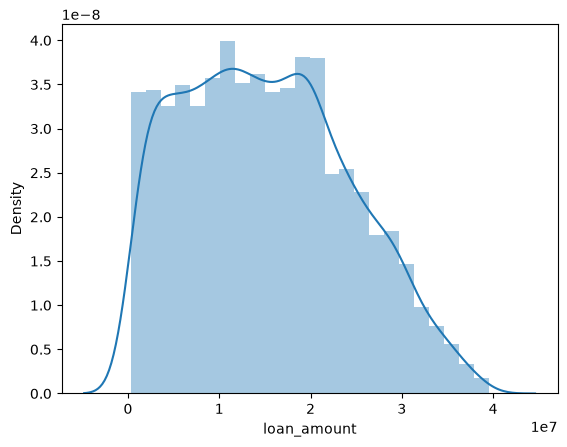

In [20]:
plt.figure(1)
sns.distplot(data['loan_amount'])
plt.show()

In [21]:
#we can see its not normal distribution 
#so we take note to make it

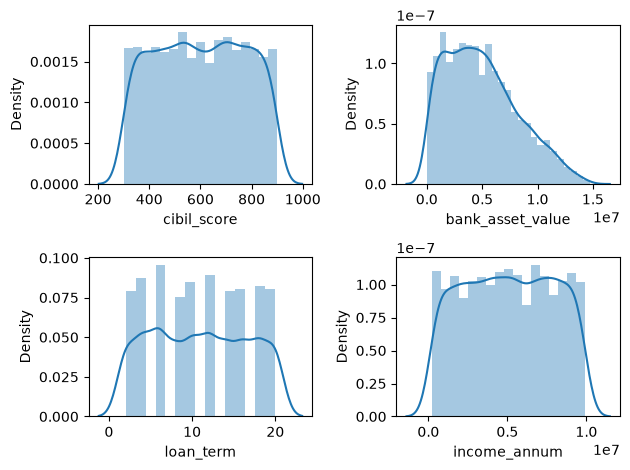

In [23]:
plt.figure(1)
plt.subplot(221)
sns.distplot(data['cibil_score'])
plt.subplot(222)
sns.distplot(data['bank_asset_value'])
plt.subplot(223)
sns.distplot(data['loan_term'])
plt.subplot(224)
sns.distplot(data['income_annum'])
plt.tight_layout()
plt.show()

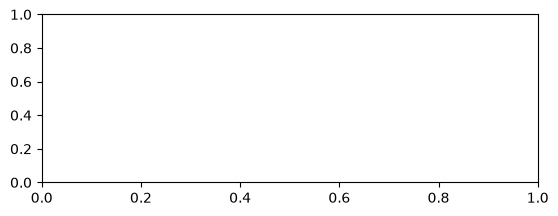

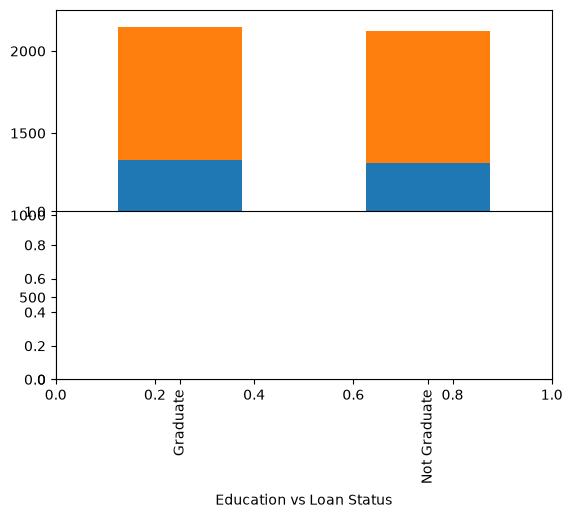

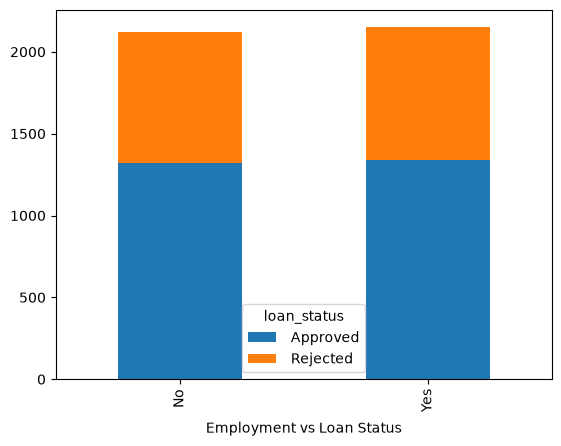

In [36]:
#now we do bivariate analysis
#how education affects loan_status
plt.figure(1)
plt.subplot(211)
Education_affect = pd.crosstab(data['education'],data['loan_status'])
Education_affect.plot(kind = 'bar',stacked = True)
plt.xlabel('Education vs Loan Status')

#how employement affects loan_status
plt.subplot(212)
Employment_affect = pd.crosstab(data['self_employed'],data['loan_status'])
Employment_affect.plot(kind = 'bar',stacked = True)
plt.xlabel('Employment vs Loan Status')
plt.show()

In [31]:
#now for bivariate ananylis of numerical data ,we can convert them into categorical 
data['income_annum'].describe().astype(int)

count       4269
mean     5059123
std      2806839
min       200000
25%      2700000
50%      5100000
75%      7500000
max      9900000
Name: income_annum, dtype: int64

In [34]:
bins = [200000,3000000,5000000,8000000,9900000]
group = ['low','average','high','very-high']
#a specical function pd.cut

data['salary'] = pd.cut(data['income_annum'],bins,labels = group)
data['salary'].head()

0    very-high
1      average
2    very-high
3    very-high
4    very-high
Name: salary, dtype: category
Categories (4, str): ['low' < 'average' < 'high' < 'very-high']

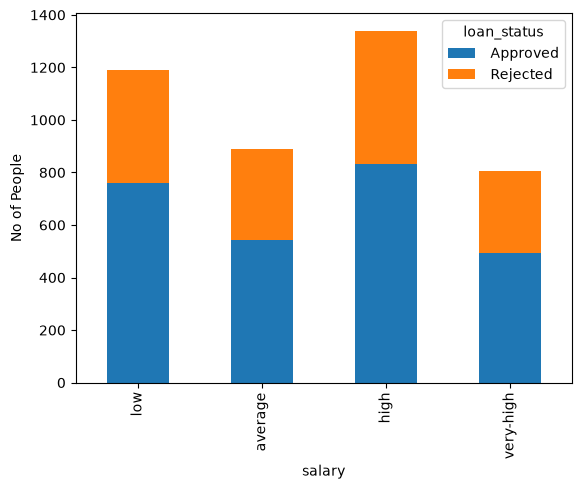

In [38]:
salary_loan_status = pd.crosstab(data['salary'],data['loan_status'])
salary_loan_status.plot(kind = 'bar',stacked = True)
plt.ylabel("No of People")
plt.show()

In [43]:
data['total_asset_value'] = data['residential_assets_value']+data['commercial_assets_value']+data['luxury_assets_value']
data['total_asset_value'].describe().astype(int)


count        4269
mean     27572077
std      16891763
min        200000
25%      13700000
50%      26200000
75%      39900000
max      81700000
Name: total_asset_value, dtype: int64

In [47]:
bins = [200000,7500000,15000000,21000000,27572077]
group = ['low','average','high','very-high']
data['total_asset_group'] = pd.cut(data['total_asset_value'],bins,labels = group)

<Axes: xlabel='total_asset_group'>

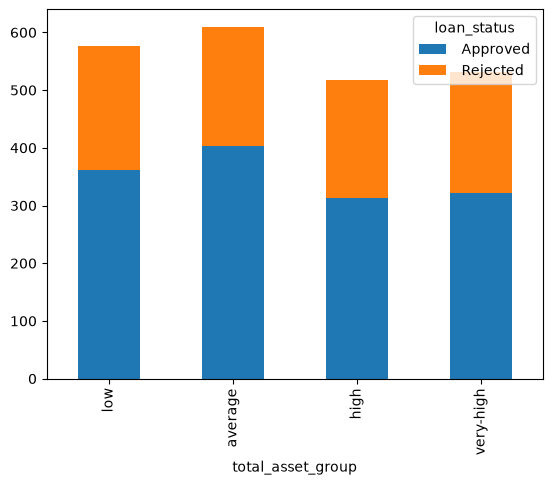

In [49]:
#Loan based on TOTAL ASSET VALUE(EXCLUDING BANK ASSET VALUE)

pd.crosstab(data['total_asset_group'],data['loan_status']).plot(kind = 'bar',stacked = True)

In [50]:
data['no_of_dependents'].value_counts()

no_of_dependents
4    752
3    727
0    712
2    708
1    697
5    673
Name: count, dtype: int64

<Axes: xlabel='no_of_dependents'>

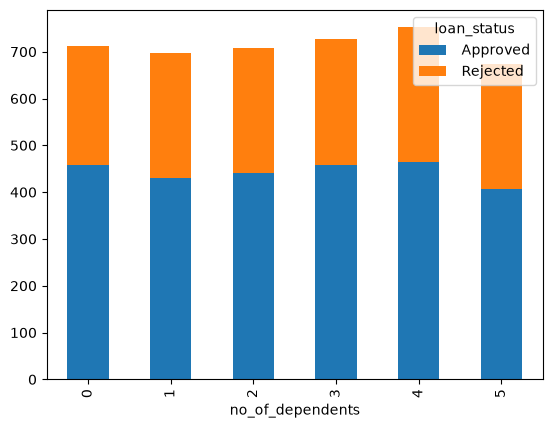

In [51]:
pd.crosstab(data['no_of_dependents'],data['loan_status']).plot(kind = 'bar',stacked = True)

In [53]:
data['cibil_score'].describe()

count    4269.000000
mean      599.936051
std       172.430401
min       300.000000
25%       453.000000
50%       600.000000
75%       748.000000
max       900.000000
Name: cibil_score, dtype: float64

<Axes: xlabel='cibil_group'>

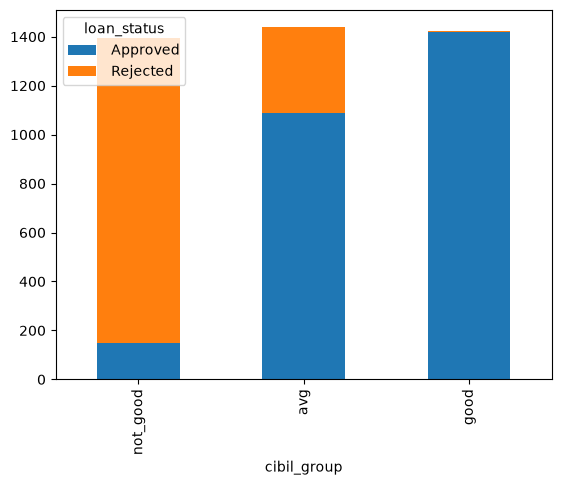

In [54]:
bins = [300,500,700,900]
group = ['not_good','avg','good']
data['cibil_group'] = pd.cut(data['cibil_score'],bins,labels = group)
pd.crosstab(data['cibil_group'],data['loan_status']).plot(kind = 'bar',stacked = True)

<Axes: xlabel='cibil_group'>

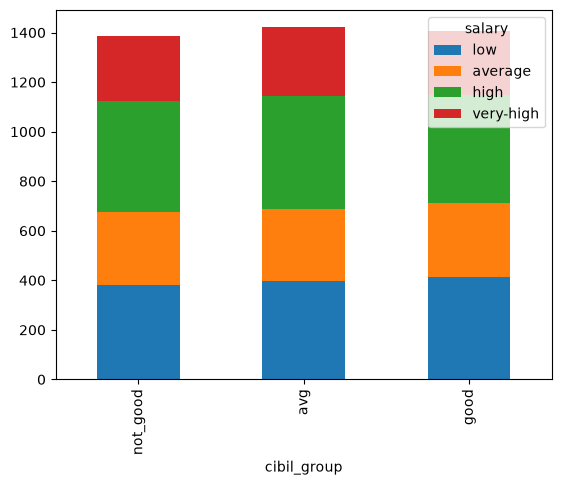

In [55]:
#we see that cibil score is a very important feature (heighest weight)
#now lets also see if cibil score is to do anything with high annual income
pd.crosstab(data['cibil_group'],data['salary']).plot(kind = 'bar',stacked = True)

In [56]:
data.columns

Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status', 'salary',
       'total_asset_value', 'totoal_asset_group', 'total_asset_group',
       'cibil_group'],
      dtype='str')

In [61]:
#so its not 
#now we drop extra features created
data.drop(columns = ['salary','cibil_group','total_asset_group','totoal_asset_group','luxury_assets_value','residential_assets_value','commercial_assets_value'],inplace = True)
#here we have not deleted total_asset_value instead deleted all residential,commercial groups


In [62]:
data.columns

Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'bank_asset_value', 'loan_status', 'total_asset_value'],
      dtype='str')

In [63]:
#now replacing some stuff
data.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,bank_asset_value,loan_status,total_asset_value
0,1,2,Graduate,No,9600000,29900000,12,778,8000000,Approved,42700000
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,3300000,Rejected,13700000
2,3,3,Graduate,No,9100000,29700000,20,506,12800000,Rejected,44900000
3,4,3,Graduate,No,8200000,30700000,8,467,7900000,Rejected,44800000
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,5000000,Rejected,50000000


In [72]:
#0 -> positive , 1 ->negatuve
data['self_employed'] = data['self_employed'].str.strip()
data['education'] = data['education'].str.strip()
data['education'].replace({"Graduate":0,"Not Graduate":1},inplace = True)
data['self_employed'].replace({"No":1,"Yes":0},inplace = True)
data['loan_status'] = data['loan_status'].str.strip()
data['loan_status'].replace({"Approved":0,"Rejected":1},inplace = True)

0       0
1       1
2       1
3       1
4       1
       ..
4264    1
4265    0
4266    1
4267    0
4268    0
Name: loan_status, Length: 4269, dtype: object

In [73]:
data.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,bank_asset_value,loan_status,total_asset_value
0,1,2,Graduate,No,9600000,29900000,12,778,8000000,Approved,42700000
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,3300000,Rejected,13700000
2,3,3,Graduate,No,9100000,29700000,20,506,12800000,Rejected,44900000
3,4,3,Graduate,No,8200000,30700000,8,467,7900000,Rejected,44800000
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,5000000,Rejected,50000000


In [ ]:
#numerical_df = data.select_dtype(include= ['int64','float64'])
#matrix = numerical_df.corr()
#sns.heatmap(matrix,vmax = 8,sqaure = True,cmap = 'BuPu')  # vmax -> any value greater than vmax will be painted with maximum color